# SnapKV Token Dropping Example with LMCache SDK
---

Long prompts create large KV caches that eat up GPU memory and limit how many 
requests fit in a batch, and a smaller batch means lower decode throughput. 
Token dropping shrinks each request's KV cache (in this example by half), so more
requests fits in a batch. This notebook shows improvement in decode 
throughput by 1.5-1.7x by using LMCache's SDK API that enables ML engineers get
a requests' KV, do optimizations such as token dropping, and put it back to use
during LLM serving.

This notebook is a short demonstration in GPU with smaller capacity:
* Google Colab GPU T4: 15GB GPU memory, 12GB RAM, shared memory capacity 5.6GB
* Shorter workload: 10 prompts @ 1024 input tokens, 128 output tokens
* LMCache L1 size follows SHM capacity: 5.6GB
* vLLM GPU memory utilization: 0.35

The amount of workload, L1 size, and GPU memory utilization should be adjusted
altogether to fit in the constrained space to emulate condition where dropping
tokens (e.g. by half) increases the batch size (e.g. by 2x).

For larger scale demonstration and experiment, please refer to 
[LMCache SDK example](https://github.com/LMCache/LMCache/tree/dev/examples/token_dropping).

## What this notebook does?

In the middle of the notebooks, please stop and click "Restart" when "Restart"
markdown appears next. Therefore, user can't do "Run all" because there are 2x
"Restart" due to the environment preparation.

**0. Prepare environment, vLLM, and LMCache**

* Google Colab GPU T4 by default is shipped with cu128. vLLM does not ship
  precompiled binary using cu128, hence we need to upgrade to cu130 to avoid
  full compilation.
* This notebook installs vLLM via vLLM's PyPI release on version 0.23.0 and
  LMCache from source code on branch get-query-tensor-v2 (currently not yet
  merged)

**1. Start LMCache server**

To use shared memory, specify the `--shm-name` and `--no-l1-use-lazy`.
To enable query tensor transfer, we pass `--enable transfer_query`.

```sh
lmcache server \
    --l1-size-gb 5.6 \
    --eviction-policy LRU \
    --chunk-size 256 \
    --port 6555 \
    --http-port 8080 \
    --shm-name lmcache_sdk \
    --no-l1-use-lazy
    --enable transfer_query
```

Although Google Colab has 12GB RAM (11GB available), LMCache on Google Colab 
throws error when used entirely. Hence, we set L1 as big as SHM capacity.
After starting LMCache, it will wait until LMCache server is ready.

**2. Start vLLM once LMCache server is ready**

We pass --no-enable-prefix-caching to disable vLLM's built-in prefix caching. 
This ensures the prefilled KV cache is always served from LMCache rather than 
vLLM, so the decoding throughput improvement can be attributed entirely to the 
tokens dropped through LMCache.

```sh
vllm serve Qwen/Qwen3-8B \
    --port 8000 \
    --served-model-name Qwen/Qwen3-8B \
    --no-enable-prefix-caching \
    --enforce-eager \
    --gpu-memory-utilization 0.65 \
    --kv-transfer-config '{"kv_connector":"LMCacheMPConnector","kv_role":"kv_both","kv_connector_extra_config":{"lmcache.mp.port":6555,"lmcache.mp.transfer_intermediate_tensors":true,"lmcache.mp.q.ring_depth":2}}' \
    --trust-remote-code \
    --return-tokens-as-token-ids
```

To enable query tensor transfer, pass 
`"lmcache.mp.transfer_intermediate_tensors":true` as an additional argument
to `--kv-transfer-config`. To adjust the QRingBuffer capacity, which holds
the query tensor temporarily before storing in L1, pass `"lmcache.mp.q.ring_depth"`
which defaults to 2 (2 means the QRingBuffer can hold the query tensors of 2
forward passes).

**3. Prepares the SDK and Evaluation**

The notebook then pulls the prepared short dataset, taken from LongBench-V2,
filtering 10 requests with length closest to 1024 tokens and unique contexts.

SDK contexts for both KV and Q are then made, and used for 2x experiments:
1. Baseline (no dropping).
2. SnapKV token dropping.

After the SDK contexts are done being used, the context is then closed and both
vLLM and LMCache process are killed.

## 0. Prepare environment, vLLM, and LMCache

In [1]:
%%bash

nvidia-smi
free -h
nvcc --version

Sun Jul 26 22:40:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os

os.environ["LMCACHE_DIR"] = "/content/LMCache"
os.environ["HF_TOKEN"] = ""  # paste HuggingFace token here

In [3]:
%%bash
set -e
cd /content
[ -d LMCache ] || git clone -q --branch get-query-tensor-v2 --single-branch \
    https://github.com/rannnayy/LMCache.git
echo "  ✓ LMCache at $LMCACHE_DIR"

  ✓ LMCache at /content/LMCache


In [4]:
%%bash
set -eox
apt-get -y install cuda-toolkit-13-0
pip install -q uv
uv pip uninstall -y vllm lmcache torch >/dev/null 2>&1 || true
uv cache clean
uv pip install --force-reinstall torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu130
python -c "import torch; print('torch cuda:', torch.version.cuda)"

allexport      	off
braceexpand    	on
emacs          	off
errexit        	on
errtrace       	off
functrace      	off
hashall        	on
histexpand     	off
history        	off
ignoreeof      	off
interactive-comments	on
keyword        	off
monitor        	off
noclobber      	off
noexec         	off
noglob         	off
nolog          	off
notify         	off
nounset        	off
onecmd         	off
physical       	off
pipefail       	off
posix          	off
privileged     	off
verbose        	off
vi             	off
xtrace         	off
Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  at-spi2-core cuda-cccl-13-0 cuda-command-line-tools-13-0 cuda-compiler-13-0
  cuda-crt-13-0 cuda-cudart-13-0 cuda-cudart-dev-13-0 cuda-culibos-dev-13-0
  cuda-cuobjdump-13-0 cuda-cupti-13-0 cuda-cupti-dev-13-0 cuda-cuxxfilt-13-0
  cuda-documentation-13-0 cuda-driver-dev-13-0 cuda-gdb-13-0
  cuda-libraries-13-0 cuda-libra

+ apt-get -y install cuda-toolkit-13-0
+ pip install -q uv
+ uv pip uninstall -y vllm lmcache torch
+ uv cache clean
Clearing cache at: /root/.cache/uv
Removed 5 files (44B)
+ uv pip install --force-reinstall torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu130
Using Python 3.12.13 environment at: /usr
Resolved 33 packages in 730ms
Prepared 33 packages in 51.86s
Uninstalled 17 packages in 264ms
Installed 33 packages in 269ms
 - cuda-bindings==12.9.7
 + cuda-bindings==13.0.3
 - cuda-pathfinder==1.5.6
 + cuda-pathfinder==1.2.2
 - cuda-toolkit==12.8.1
 + cuda-toolkit==13.0.3.0
 - filelock==3.29.7
 + filelock==3.29.0
 - fsspec==2025.3.0
 + fsspec==2026.4.0
 ~ jinja2==3.1.6
 ~ markupsafe==3.0.3
 ~ mpmath==1.3.0
 ~ networkx==3.6.1
 - numpy==2.0.2
 + numpy==2.4.4
 + nvidia-cublas==13.1.1.3
 + nvidia-cuda-cupti==13.0.85
 + nvidia-cuda-nvrtc==13.0.88
 + nvidia-cuda-runtime==13.0.96
 + nvidia-cudnn-cu13==9.20.0.48
 + nvidia-cufft==12.0.0.61
 + nvidia-cufile==1.15.1.6
 

In [5]:
%%bash
set -eox
export MAX_JOBS="$(nproc)"
uv pip install --force-reinstall --no-cache-dir vllm==0.23.0

allexport      	off
braceexpand    	on
emacs          	off
errexit        	on
errtrace       	off
functrace      	off
hashall        	on
histexpand     	off
history        	off
ignoreeof      	off
interactive-comments	on
keyword        	off
monitor        	off
noclobber      	off
noexec         	off
noglob         	off
nolog          	off
notify         	off
nounset        	off
onecmd         	off
physical       	off
pipefail       	off
posix          	off
privileged     	off
verbose        	off
vi             	off
xtrace         	off


++ nproc
+ export MAX_JOBS=2
+ MAX_JOBS=2
+ uv pip install --force-reinstall --no-cache-dir vllm==0.23.0
Using Python 3.12.13 environment at: /usr
Resolved 190 packages in 1.95s
Prepared 190 packages in 1m 40s
Uninstalled 121 packages in 1.30s
Installed 190 packages in 1.39s
 ~ aiohappyeyeballs==2.7.1
 - aiohttp==3.14.1
 + aiohttp==3.14.3
 ~ aiosignal==1.4.0
 ~ annotated-doc==0.0.4
 - annotated-types==0.7.0
 + annotated-types==0.8.0
 + anthropic==0.120.0
 ~ anyio==4.14.2
 + apache-tvm-ffi==0.1.9
 + astor==0.8.1
 ~ attrs==26.1.0
 + blake3==1.0.9
 - cachetools==6.2.6
 + cachetools==7.1.6
 + cbor2==6.1.3
 - certifi==2026.6.17
 + certifi==2026.7.22
 ~ cffi==2.1.0
 ~ charset-normalizer==3.4.9
 ~ click==8.4.2
 ~ cloudpickle==3.1.2
 + compressed-tensors==0.17.0
 ~ cryptography==49.0.0
 - cuda-bindings==13.0.3
 + cuda-bindings==13.3.1
 - cuda-core==0.3.2
 + cuda-core==1.0.1
 - cuda-pathfinder==1.2.2
 + cuda-pathfinder==1.6.0
 - cuda-python==12.9.7
 + cuda-python==13.3.1
 + cuda-tile==1.3.0
 - 

In [6]:
%%bash
python -c "import vllm; print(vllm.__file__, vllm.__version__)"
python -c "import torch; print('torch CUDA build:', torch.version.cuda)"
python -c "import torch, vllm; print('torch cuda:', torch.version.cuda, '| vllm', vllm.__version__)"
vllm --version

/usr/local/lib/python3.12/dist-packages/vllm/__init__.py 0.23.0
torch CUDA build: 13.0
torch cuda: 13.0 | vllm 0.23.0
0.23.0


In [7]:
%%bash
set -euo pipefail
DIFF="/content/LMCache/examples/token_dropping/vllm-export-intermediate-tensors.diff"

[ -f "$DIFF" ] || { echo "!! diff not found at: $DIFF"; exit 1; }

SITE=$(python -c "import vllm, os; print(os.path.dirname(os.path.dirname(vllm.__file__)))")
cd "$SITE"
if patch -p1 --forward --dry-run < "$DIFF" >/dev/null 2>&1; then
    patch -p1 --forward < "$DIFF" >/dev/null && echo "  ✓ patch applied to $SITE/vllm"
elif patch -p1 -R --dry-run < "$DIFF" >/dev/null 2>&1; then
    echo "  ✓ patch already present (skipping)"
else
    echo "  !! PATCH FAILED: this vLLM release differs from the diff's base."
    exit 1
fi

  ✓ patch applied to /usr/local/lib/python3.12/dist-packages/vllm


In [8]:
%%bash
cd /content/LMCache/ && pwd
echo ${LMCACHE_DIR}

/content/LMCache
/content/LMCache


In [9]:
%%bash
set -eox
cd "$LMCACHE_DIR"
find lmcache -name '*.so' -delete 2>/dev/null || true
rm -rf build/
uv pip install --force-reinstall --system -q --editable . --no-build-isolation --no-deps
uv pip install --system "opentelemetry-exporter-prometheus==0.65b0"
echo "  ✓ lmcache installed"

allexport      	off
braceexpand    	on
emacs          	off
errexit        	on
errtrace       	off
functrace      	off
hashall        	on
histexpand     	off
history        	off
ignoreeof      	off
interactive-comments	on
keyword        	off
monitor        	off
noclobber      	off
noexec         	off
noglob         	off
nolog          	off
notify         	off
nounset        	off
onecmd         	off
physical       	off
pipefail       	off
posix          	off
privileged     	off
verbose        	off
vi             	off
xtrace         	off
  ✓ lmcache installed


+ cd /content/LMCache
+ find lmcache -name '*.so' -delete
+ rm -rf build/
+ uv pip install --force-reinstall --system -q --editable . --no-build-isolation --no-deps
+ uv pip install --system opentelemetry-exporter-prometheus==0.65b0
Using Python 3.12.13 environment at: /usr
Resolved 6 packages in 152ms
Prepared 1 package in 11ms
Installed 1 package in 1ms
 + opentelemetry-exporter-prometheus==0.65b0
+ echo '  ✓ lmcache installed'


In [10]:
import os
import sys
import subprocess

print("LMCACHE_DIR (env):", os.environ.get("LMCACHE_DIR"))
print("python:", sys.executable)
out = subprocess.run(["pip", "show", "lmcache"], capture_output=True, text=True).stdout
print(out or "not successfully installed")

LMCACHE_DIR (env): /content/LMCache
python: /usr/bin/python3
Name: lmcache
Version: 0.0.0
Summary: A LLM serving engine extension to reduce TTFT and increase throughput, especially under long-context scenarios.
Home-page: https://docs.lmcache.ai
Author: 
Author-email: LMCache Team <lmcacheteam@gmail.com>
License: 
Location: /usr/local/lib/python3.12/dist-packages
Editable project location: /content/LMCache
Requires: aiofile, aiofiles, aiohttp, awscrt, blake3, cachetools, cufile-python, cupy-cuda13x, fastapi, google-api-core, google-cloud-bigtable, httptools, httpx, huggingface_hub, msgspec, numba, numpy, nvtx, opentelemetry-api, opentelemetry-exporter-otlp, opentelemetry-exporter-prometheus, opentelemetry-sdk, prometheus_client, psutil, py-cpuinfo, pytest, pyyaml, pyzmq, redis, safetensors, setuptools, setuptools_scm, sortedcontainers, torch, transformers, uvicorn
Required-by: 



## Restart

## 1 and 2. Run LMCache and vLLM

In [1]:
import lmcache

print(lmcache.__file__, lmcache.__version__)

[2026-07-26 22:58:23,438] LMCache INFO: torch_dev=<module 'torch.cuda' from '/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py'>, torch_device_type=cuda (__init__.py:249:lmcache.v1.platform)
[2026-07-26 22:58:24,908] LMCache INFO: Using backend: lmcache.c_ops (__init__.py:239:lmcache.v1.platform)


/content/LMCache/lmcache/__init__.py unknown


In [ ]:
import os

os.environ["LMCACHE_DIR"] = "/content/LMCache"
os.environ["HF_TOKEN"] = ""  # paste HuggingFace token here

In [3]:
%%bash
uv pip install -q hf_transfer
HF_HUB_ENABLE_HF_TRANSFER=1 hf download Qwen/Qwen3-1.7B

✓ Downloaded
  path: /root/.cache/huggingface/hub/models--Qwen--Qwen3-1.7B/snapshots/70d244cc86ccca08cf5af4e1e306ecf908b1ad5e


/usr/local/lib/python3.12/dist-packages/huggingface_hub/constants.py:298: FutureWarning: The `HF_HUB_ENABLE_HF_TRANSFER` environment variable is deprecated as 'hf_transfer' is not used anymore. Please use `HF_XET_HIGH_PERFORMANCE` instead to enable high performance transfer with Xet. Visit https://huggingface.co/docs/huggingface_hub/package_reference/environment_variables#hfxethighperformance for more details.
  warnings.warn(
Fetching 12 files: 100%|██████████| 12/12 [00:23<00:00,  1.93s/it]


In [4]:
%%bash
python -c "import torch; print('installed torch:', torch.__version__)"

installed torch: 2.11.0+cu130


In [5]:
%%bash
df -h /dev/shm
free -h
ls -la /dev/shm/lmcache*
rm -f /dev/shm/lmcache_l1_pool_lmcache_sdk

Filesystem      Size  Used Avail Use% Mounted on
shm             5.7G     0  5.7G   0% /dev/shm
               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.2Gi       1.1Gi       2.0Mi        10Gi        11Gi
Swap:             0B          0B          0B


ls: cannot access '/dev/shm/lmcache*': No such file or directory


In [ ]:
!pgrep -af "lmcache server" || echo "LMCache: NOT running"
!pgrep -af "vllm serve"     || echo "vLLM:    NOT running"

7404 /bin/bash -c pgrep -af "lmcache server" || echo "LMCache: NOT running"
7406 /bin/bash -c pgrep -af "vllm serve"     || echo "vLLM:    NOT running"


In [7]:
!uv pip install --system "opentelemetry-exporter-prometheus==0.65b0"

Using Python 3.12.13 environment at: /usr
Checked 1 package in 93ms


In [ ]:
import os
import time
import subprocess
import urllib.request

LOG = "/content/logs"
os.makedirs(LOG, exist_ok=True)
lmc_log, vllm_log = f"{LOG}/lmcache.log", f"{LOG}/vllm.log"

os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"


def launch(cmd, log_path):
    f = open(log_path, "w")
    return subprocess.Popen(
        cmd, stdout=f, stderr=subprocess.STDOUT, start_new_session=True
    )


def wait_ready(url, name, proc, log_path, timeout):
    t0 = time.time()
    while time.time() - t0 < timeout:
        if proc.poll() is not None:
            print(f"✗ {name} exited early (code {proc.returncode}). Last log lines:\n")
            print(open(log_path).read()[-3000:])
            return False
        try:
            with urllib.request.urlopen(url, timeout=5) as r:
                if r.status == 200:
                    print(f"✓ {name} ready in {int(time.time() - t0)}s")
                    return True
        except Exception:
            pass
        el = int(time.time() - t0)
        if el and el % 15 == 0:
            last = (open(log_path).read().strip().splitlines() or [""])[-1]
            print(f"  … waiting for {name} ({el}s)  | {last[-100:]}")
        time.sleep(3)
    print(f"✗ {name} not ready after {timeout}s. Last log lines:\n")
    print(open(log_path).read()[-3000:])
    return False


# 1) LMCache server (background) → wait until up
lmc = launch(
    [
        "lmcache",
        "server",
        "--l1-size-gb",
        "3",
        "--eviction-policy",
        "LRU",
        "--chunk-size",
        "256",
        "--port",
        "6555",
        "--http-port",
        "8081",
        "--shm-name",
        "lmcache_sdk",
        "--no-l1-use-lazy",
        "--enable",
        "transfer_query",
        "--max-workers",
        "4",
        "--eviction-trigger-watermark",
        "0.98",
    ],
    lmc_log,
)
print(f"LMCache PID {lmc.pid} → {lmc_log}")

if wait_ready(
    "http://localhost:8081/healthcheck", "LMCache", lmc, lmc_log, timeout=180
):
    # 2) vLLM (background) → wait until up
    vllm = launch(
        [
            "vllm",
            "serve",
            "Qwen/Qwen3-1.7B",
            "--port",
            "8000",
            "--served-model-name",
            "Qwen/Qwen3-1.7B",
            "--no-enable-prefix-caching",
            "--enforce-eager",
            "--gpu-memory-utilization",
            "0.35",
            "--kv-transfer-config",
            '{"kv_connector":"LMCacheMPConnector","kv_role":"kv_both","kv_connector_extra_config":{"lmcache.mp.port":6555,"lmcache.mp.transfer_intermediate_tensors":true,"lmcache.mp.heartbeat_interval":30}}',
            "--trust-remote-code",
            "--return-tokens-as-token-ids",
            "--max-model-len",
            "2048",
            "--max-num-batched-tokens",
            "2048",
            "--attention-backend",
            "TRITON_ATTN",
        ],
        vllm_log,
    )
    print(f"vLLM PID {vllm.pid} → {vllm_log}")
    wait_ready("http://localhost:8000/v1/models", "vLLM", vllm, vllm_log, timeout=1800)

LMCache PID 7505 → /content/logs/lmcache.log
✓ LMCache ready in 9s
vLLM PID 7585 → /content/logs/vllm.log
  … waiting for vLLM (15s)  |   warnings.warn(
  … waiting for vLLM (30s)  | ING 07-26 22:59:55 [envs.py:2088] Unknown vLLM environment variable detected: VLLM_ATTENTION_BACKEND
  … waiting for vLLM (45s)  | ING 07-26 22:59:55 [envs.py:2088] Unknown vLLM environment variable detected: VLLM_ATTENTION_BACKEND
  … waiting for vLLM (60s)  | ver pid=7585) INFO 07-26 23:00:18 [compilation.py:321] Enabled custom fusions: norm_quant, act_quant
  … waiting for vLLM (75s)  | m=['vllm_c', 'native']), enable_flashinfer_autotune=True, moe_backend='auto', linear_backend='auto')
  … waiting for vLLM (90s)  | Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]
  … waiting for vLLM (105s)  |  IPC (vllm_multi_process_adapter.py:158:lmcache.integration.vllm.vllm_multi_process_adapter)
  … waiting for vLLM (120s)  |  IPC (vllm_multi_process_adapter.py:158:lmcache.integration.v

In [9]:
!pgrep -af "lmcache server" || echo "LMCache: NOT running"
!pgrep -af "vllm serve"     || echo "vLLM:    NOT running"

7505 /usr/bin/python3 /usr/local/bin/lmcache server --l1-size-gb 3 --eviction-policy LRU --chunk-size 256 --port 6555 --http-port 8081 --shm-name lmcache_sdk --no-l1-use-lazy --enable transfer_query --max-workers 4 --eviction-trigger-watermark 0.98
9186 /bin/bash -c pgrep -af "lmcache server" || echo "LMCache: NOT running"
7585 /usr/bin/python3 /usr/local/bin/vllm serve Qwen/Qwen3-1.7B --port 8000 --served-model-name Qwen/Qwen3-1.7B --no-enable-prefix-caching --enforce-eager --gpu-memory-utilization 0.35 --kv-transfer-config {"kv_connector":"LMCacheMPConnector","kv_role":"kv_both","kv_connector_extra_config":{"lmcache.mp.port":6555,"lmcache.mp.transfer_intermediate_tensors":true,"lmcache.mp.heartbeat_interval":30}} --trust-remote-code --return-tokens-as-token-ids --max-model-len 2048 --max-num-batched-tokens 2048 --attention-backend TRITON_ATTN
9188 /bin/bash -c pgrep -af "vllm serve"     || echo "vLLM:    NOT running"


In [5]:
%%bash
ps -o pid,pgid,cmd -p 7682
kill -KILL -7682

    PID    PGID CMD
   7682    7682 /usr/bin/python3 /usr/local/bin/lmcache server --l1-size-gb 3 --eviction-policy LRU --chunk-size 256 --port 6555 --http-port 8081 --shm-name lmcache_sdk --no-l1-use-lazy --enable transfer_query --max-workers 4 --eviction-trigger-watermark 0.98


In [ ]:
!uv pip install --system --force-reinstall --no-cache-dir numpy=={numpy.__version__}

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 238.3 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.5
    Uninstalling numpy-2.3.5:
      Successfully uninstalled numpy-2.3.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
lmcache 0.0.0 requires aiofile, which is not installed.
lmcache 0.0.0 requires awscrt, which is not installed.
lmcache 0.0.0 requires cufile-python, which is not installed.
lmcache 0.0.0 requires cupy-cuda13x, which is not installed.
lmcache 0.0.0 requires google-cloud-bigtable, which is not installed.
lmcache 0.0.0 requires redis, which is not installed.
lmcache 0.0.0 requires setuptools_scm>=8, which is not installed.
lmcache 0.0.0 requires numpy<=2.2.6, but you have numpy 2.3.5 which is incompatible.

In [11]:
%%bash

nvidia-smi

Sun Jul 26 23:05:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   71C    P0             31W /   70W |    6731MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Restart

## 3. Prepare SDK and Evaluation

In [1]:
%%bash

pwd && cd /content/LMCache/examples/token_dropping && pwd

/content
/content/LMCache/examples/token_dropping


In [ ]:
# ruff: noqa: E402

# Standard
from datasets import load_dataset
import math
import matplotlib.pyplot as plt
import os
import sys
from transformers import AutoTokenizer, AutoConfig

NB_DIR = "/content/LMCache/examples/token_dropping"
if NB_DIR not in sys.path:
    sys.path.insert(0, NB_DIR)

# Third Party
import torch
import torch.nn.functional as F

# First Party
from lmcache.logging import init_logger
import lmcache.sdk as lmc_sdk
from lmcache.banner import print_banner_once
from utils import (
    rerotate_k_cache,
    make_post_completion,
    score_answers,
)

print_banner_once(sys.stdout)
logger = init_logger(__name__)

[2026-07-26 23:05:28,045] LMCache INFO: torch_dev=<module 'torch.cuda' from '/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py'>, torch_device_type=cuda (__init__.py:249:lmcache.v1.platform)
[2026-07-26 23:05:28,556] LMCache INFO: Using backend: lmcache.c_ops (__init__.py:239:lmcache.v1.platform)
[2026-07-26 23:05:28,740] LMCache INFO: multi_layer_block_kv_transfer mode: ptr (base.py:94:lmcache.v1.multiprocess.transfer_context.base)



 _     __  __    ____           _          
| |   |  \/  |  / ___|__ _  ___| |__   ___      LMCache vunknown
| |   | |\/| | | |   / _` |/ __| '_ \ / _ \     Website:  https://lmcache.ai/
| |___| |  | | | |__| (_| | (__| | | |  __/     Recipes:  https://docs.lmcache.ai/recipes
|_____|_|  |_|  \____\__,_|\___|_| |_|\___|     LinkedIn: https://www.linkedin.com/company/lmcache-lab
Set LMCACHE_DISABLE_BANNER=1 to hide this banner.



## Setting up hyperparameters

In [3]:
model_name = "Qwen/Qwen3-1.7B"
vllm_url = "http://localhost:8000"
lmcache_url = "http://localhost:8081"
lmcache_mq_url = "tcp://localhost:6555"
chunk_size = 256
max_tokens = 256
temperature = 0.0  # greedy decode so generated answers are deterministic and scorable
timeout = 60  # timeout for context retrieval (seconds)
trust_remote_code = True

In [ ]:
import os

os.environ["LMCACHE_DIR"] = "/content/LMCache"
os.environ["HF_TOKEN"] = ""  # paste HuggingFace token here

## Configuring the model and LMCache endpoint

In [5]:
tokenizer = AutoTokenizer.from_pretrained(
    model_name, trust_remote_code=trust_remote_code
)
config = AutoConfig.from_pretrained(model_name, trust_remote_code=trust_remote_code)
work_device = torch.device("cpu")
post_completion = make_post_completion(vllm_url, model_name, timeout)
ctx = lmc_sdk.kvcache.connect(
    url=lmcache_mq_url,
    http_url=lmcache_url,
    model_name=model_name,
    timeout=timeout,
)
qctx = lmc_sdk.qcache.connect(
    url=lmcache_mq_url,
    http_url=lmcache_url,
    model_name=model_name,
    timeout=timeout,
)

[2026-07-26 23:05:32,374] LMCache INFO: Initialized LMCacheSDKContext with instance_id=4548503554047806169, model_name=Qwen/Qwen3-1.7B, chunk_size=256, shm_name=lmcache_l1_pool_lmcache_sdk, kind=LMCacheSDKCacheKind.KV (context.py:159:lmcache.sdk.context)
[2026-07-26 23:05:32,379] LMCache INFO: Creating transfer context (device_type=cpu, mode=auto) (worker_transfer.py:769:lmcache.v1.multiprocess.transfer_context.worker_transfer)
[2026-07-26 23:05:32,595] LMCache INFO: Using AsyncEngineDrivenTransferContext for store path (worker_transfer.py:100:lmcache.v1.multiprocess.transfer_context.worker_transfer)
[2026-07-26 23:05:33,909] LMCache INFO: Engine KV Format: EngineKVFormat.NL_X_NB_TWO_NH_BS_HS NL x [NB, 2, NH, BS, HS] (detection.py:44:lmcache.v1.gpu_connector.kv_format.detection)
[2026-07-26 23:05:33,913] LMCache INFO: Creating EngineDrivenContextShm (shm_name=lmcache_l1_pool_lmcache_sdk, pool_size=3221225472) (base.py:235:lmcache.v1.multiprocess.transfer_context.base)
[2026-07-26 23:05

## Constructing Prompt

In [ ]:
prompts = []
answers = []
ds = load_dataset("raniayu/token-dropping-demo-short", split="train")
count = 0
for i, example in enumerate(ds):
    prompt = tokenizer.encode(ds[i]["prompt"], return_tensors="pt").squeeze(0).tolist()
    prompts.append(prompt)
    answers.append(ds[i]["answer"])

print(f"Loaded {len(prompts)} prompts from the dataset.")
print(f"Total prompts length: {sum(len(p) for p in prompts)} tokens.")
print(f"Mean prompt length: {sum(len(p) for p in prompts) / len(prompts):.2f} tokens.")
print(f"Max prompt length: {max(len(p) for p in prompts)} tokens.")
print(f"Min prompt length: {min(len(p) for p in prompts)} tokens.")

README.md:   0%|          | 0.00/303 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 52.9kB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/20 [00:00<?, ? examples/s]

Loaded 10 prompts from the dataset.
Total prompts length: 10105 tokens.
Mean prompt length: 1010.50 tokens.
Max prompt length: 1138 tokens.
Min prompt length: 899 tokens.


## Baseline (without token dropping)

In [ ]:
batch = lmc_sdk.batch.LMCacheBatchedStream()
for i, prompt in enumerate(prompts):
    request = lmc_sdk.request.create_request(
        contexts=[ctx, qctx],
        post_completion=post_completion,
        prompt_token_ids=prompt,
    )
    batch.add(request)
results = batch.prefill(
    sampling_params={"max_tokens": 1, "temperature": 1.0, "ignore_eos": True}
)
results.emit()

logger.info("\n\n")

results = batch.decode(
    sampling_params={
        "max_tokens": max_tokens,
        "temperature": temperature,
        "ignore_eos": True,
    }
)
results.emit()
before_drop_data = results.to_dict()
before_texts = [request.output_text for request in batch.request_streams.values()]

[2026-07-26 23:09:06,429] LMCache INFO: 

 (4183367363.py:14:__main__)


======================= Batched Stream Metrics (prefill) =======================
-------------------------------- Configuration ---------------------------------
Number of Streams:                                                            10
----------------------------------- Results ------------------------------------
Total Duration (s):                                                         5.95
Total Input Tokens:                                                        10105
Input Throughput (tokens/s):                                             1698.07
======================= Batched Stream Metrics (decode) ========================
-------------------------------- Configuration ---------------------------------
Number of Streams:                                                            10
----------------------------------- Results ------------------------------------
Total Duration (s):                                                        17.07
Total Output Tokens:        

## Clear LMCache

In [10]:
!curl -X POST {lmcache_url}/cache/clear

{"status":"ok","cleared":{"tier":"l1"}}

## With Token Dropping

In [ ]:
snapkv_window_size = 64
snapkv_drop_ratio = 0.5
snapkv_kernel_size = 5
snapkv_pooling = "avgpool"


def _normalize_q_tensor(q_tensor: torch.Tensor) -> torch.Tensor:
    """Return q as [num_layers, T, num_q_heads * head_size]."""
    if q_tensor.ndim == 4:
        if q_tensor.shape[0] != 1:
            raise ValueError(f"expected q_tensor first dim 1, got {q_tensor.shape}")
        return q_tensor[0]
    if q_tensor.ndim == 3:
        return q_tensor
    raise ValueError(f"expected q_tensor 3D or 4D, got {q_tensor.shape}")


def _snapkv_layer_scores(
    k_flat: torch.Tensor,
    q_flat: torch.Tensor,
    *,
    seq_len: int,
    window_size: int,
    kernel_size: int,
    pooling: str,
    num_kv_heads: int,
    num_q_heads: int,
    head_size: int,
    device: torch.device,
) -> torch.Tensor:
    """Return one importance score per non-window past token."""
    if num_q_heads % num_kv_heads != 0:
        raise ValueError(
            f"num_q_heads ({num_q_heads}) must be divisible by "
            f"num_kv_heads ({num_kv_heads})"
        )

    groups = num_q_heads // num_kv_heads
    past_len = seq_len - window_size

    k = k_flat[:seq_len].to(device=device, dtype=torch.float32)
    q = q_flat[:seq_len].to(device=device, dtype=torch.float32)

    k = k.reshape(seq_len, num_kv_heads, head_size).permute(1, 0, 2)
    q = q.reshape(seq_len, num_q_heads, head_size)
    q = q.reshape(seq_len, num_kv_heads, groups, head_size)
    q_recent = q[-window_size:].permute(1, 2, 0, 3)

    attn = torch.einsum("kgwd,ktd->kgwt", q_recent, k) / math.sqrt(head_size)

    causal = torch.triu(
        torch.full(
            (window_size, window_size),
            torch.finfo(attn.dtype).min,
            dtype=attn.dtype,
            device=device,
        ),
        diagonal=1,
    )
    attn[..., -window_size:] += causal

    attn = F.softmax(attn, dim=-1, dtype=torch.float32)
    past_scores = attn[..., :past_len].sum(dim=-2)

    channels = past_scores.reshape(1, -1, past_len)
    if pooling == "avgpool":
        channels = F.avg_pool1d(
            channels, kernel_size=kernel_size, padding=kernel_size // 2, stride=1
        )
    elif pooling == "maxpool":
        channels = F.max_pool1d(
            channels, kernel_size=kernel_size, padding=kernel_size // 2, stride=1
        )
    else:
        raise ValueError(f"Pooling method not supported: {pooling}")

    return channels[..., :past_len].reshape(-1, past_len).mean(dim=0)


def drop_tokens_fn(
    tensors: dict[lmc_sdk.context.LMCacheSDKCacheKind, torch.Tensor],
    token_source: list[int],
) -> tuple[torch.Tensor, list[int]]:
    """SnapKV token dropping: keep top-scored past tokens plus the last window."""
    q_tensor = tensors[lmc_sdk.context.LMCacheSDKCacheKind.QUERY]
    kv_tensor = tensors[lmc_sdk.context.LMCacheSDKCacheKind.KV]

    q_by_layer = _normalize_q_tensor(q_tensor)

    seq_len = min(kv_tensor.shape[2], q_by_layer.shape[1], len(token_source))

    num_q_heads = config.num_attention_heads
    num_kv_heads = getattr(config, "num_key_value_heads", num_q_heads)
    head_dim = getattr(config, "head_dim", config.hidden_size // num_q_heads)

    if kv_tensor.shape[-1] != num_kv_heads * head_dim:
        raise ValueError(
            f"KV hidden dim {kv_tensor.shape[-1]} != {num_kv_heads * head_dim}"
        )
    if q_by_layer.shape[-1] != num_q_heads * head_dim:
        raise ValueError(
            f"Q hidden dim {q_by_layer.shape[-1]} != {num_q_heads * head_dim}"
        )

    past_len = seq_len - snapkv_window_size
    if past_len <= 0:
        raise ValueError(
            f"seq_len ({seq_len}) must exceed window ({snapkv_window_size})"
        )

    # Total tokens to retain, including recent window here
    total_keep = int(round(seq_len * (1 - snapkv_drop_ratio)))
    keep_past = max(0, min(total_keep - snapkv_window_size, past_len))

    scores = torch.zeros(past_len, dtype=torch.float32, device=work_device)
    for layer in range(kv_tensor.shape[1]):
        scores += _snapkv_layer_scores(
            kv_tensor[0, layer],
            q_by_layer[layer],
            seq_len=seq_len,
            window_size=snapkv_window_size,
            kernel_size=snapkv_kernel_size,
            pooling=snapkv_pooling,
            num_kv_heads=num_kv_heads,
            num_q_heads=num_q_heads,
            head_size=head_dim,
            device=work_device,
        )
    scores /= kv_tensor.shape[1]

    past_keep = torch.topk(scores, k=keep_past, largest=True).indices.sort().values
    last_window = torch.arange(past_len, seq_len, device=work_device)
    keep_idx = torch.cat([past_keep, last_window]).to(dtype=torch.long)
    # keep_idx = torch.arange(seq_len, device=work_device)

    keep_idx_cpu = keep_idx.cpu()
    kept_ids = [token_source[i] for i in keep_idx_cpu.tolist()]

    import gc

    del q_tensor, q_by_layer
    gc.collect()

    total_tokens = kv_tensor.shape[2]
    e_kv = rerotate_k_cache(
        kv_tensor[:, :, keep_idx_cpu, :].to(work_device),
        old_positions=keep_idx,
        new_positions=torch.arange(keep_idx.numel(), device=work_device),
        model_config=config,
    )

    logger.info(f"compacted {e_kv.shape[2]}/{total_tokens} tokens.")

    return e_kv.cpu(), kept_ids

In [ ]:
stream_ids = []

batch = lmc_sdk.batch.LMCacheBatchedStream()
for i, prompt in enumerate(prompts):
    if i >= 15:
        break
    request = lmc_sdk.request.create_request(
        contexts=[ctx, qctx],
        post_completion=post_completion,
        prompt_token_ids=prompt,
    )
    batch.add(request)
    stream_ids.append(request.request_stream_id)

results = batch.prefill(
    sampling_params={"max_tokens": 1, "temperature": 1.0, "ignore_eos": True}
)
results.emit()

logger.info("\n\n")

results = batch.modify(drop_tokens_fn)
results.emit()

logger.info("\n\n")

results = batch.decode(
    sampling_params={
        "max_tokens": max_tokens,
        "temperature": temperature,
        "ignore_eos": True,
    }
)
results.emit()
after_drop_data = results.to_dict()
after_texts = [request.output_text for request in batch.request_streams.values()]

[2026-07-26 23:13:03,528] LMCache INFO: 

 (297832851.py:20:__main__)


======================= Batched Stream Metrics (prefill) =======================
-------------------------------- Configuration ---------------------------------
Number of Streams:                                                            10
----------------------------------- Results ------------------------------------
Total Duration (s):                                                         3.48
Total Input Tokens:                                                        10105
Input Throughput (tokens/s):                                             2899.85


[2026-07-26 23:13:11,711] LMCache INFO: compacted 384/768 tokens. (840522612.py:153:__main__)
[2026-07-26 23:13:11,822] LMCache INFO: compacted 384/768 tokens. (840522612.py:153:__main__)
[2026-07-26 23:13:12,285] LMCache INFO: compacted 384/768 tokens. (840522612.py:153:__main__)
[2026-07-26 23:13:12,300] LMCache INFO: compacted 384/768 tokens. (840522612.py:153:__main__)
[2026-07-26 23:13:12,426] LMCache INFO: compacted 384/768 tokens. (840522612.py:153:__main__)
[2026-07-26 23:13:12,545] LMCache INFO: compacted 512/1024 tokens. (840522612.py:153:__main__)
[2026-07-26 23:13:12,656] LMCache INFO: compacted 512/1024 tokens. (840522612.py:153:__main__)
[2026-07-26 23:13:12,684] LMCache INFO: compacted 512/1024 tokens. (840522612.py:153:__main__)
[2026-07-26 23:13:12,722] LMCache INFO: compacted 512/1024 tokens. (840522612.py:153:__main__)
[2026-07-26 23:13:12,769] LMCache INFO: compacted 512/1024 tokens. (840522612.py:153:__main__)
[2026-07-26 23:13:12,847] LMCache INFO: 

 (297832851.p

======================== Batched Stream Modify Metrics =========================
----------------------------------- Results ------------------------------------
Total Duration (s):                                                         9.32
======================= Batched Stream Metrics (decode) ========================
-------------------------------- Configuration ---------------------------------
Number of Streams:                                                            10
----------------------------------- Results ------------------------------------
Total Duration (s):                                                        12.24
Total Output Tokens:                                                        2560
Decode Throughput (tokens/s):                                             209.12


### Accuracy

In [13]:
before_correct, total, before_map = score_answers(answers, before_texts)
after_correct, total, after_map = score_answers(answers, after_texts)
logger.info(
    f"Baseline (no drop): {before_correct}/{total} correct "
    f"({100 * before_correct / total:.1f}%)"
)
logger.info(
    f"Token dropping: {after_correct}/{total} correct "
    f"({100 * after_correct / total:.1f}%)"
)

[2026-07-26 23:15:39,845] LMCache INFO: Baseline (no drop): 8/10 correct (80.0%) (3655945089.py:3:__main__)
[2026-07-26 23:15:39,848] LMCache INFO: Token dropping: 7/10 correct (70.0%) (3655945089.py:7:__main__)


## Result Plot

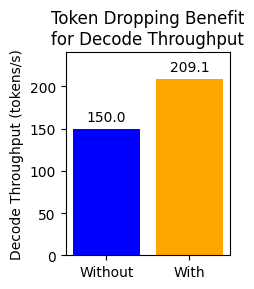

In [14]:
labels = ["Without", "With"]
data = [
    before_drop_data["metrics"]["results"]["output_tput"],
    after_drop_data["metrics"]["results"]["output_tput"],
]

fig, ax = plt.subplots(figsize=(2.5, 3))
bars = ax.bar(labels, data, color=["blue", "orange"])
ax.bar_label(bars, fmt="%.1f", padding=3)
ax.set_ylabel("Decode Throughput (tokens/s)")
ax.set_title("Token Dropping Benefit\nfor Decode Throughput")
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

## Close both contexts

In [15]:
# Only close the context when done.
ctx.close()
qctx.close()

## Print the PID of both LMCache and vLLM processes, then kill them

In [ ]:
!pgrep -af "lmcache server"
!pgrep -af "vllm serve"

7505 /usr/bin/python3 /usr/local/bin/lmcache server --l1-size-gb 3 --eviction-policy LRU --chunk-size 256 --port 6555 --http-port 8081 --shm-name lmcache_sdk --no-l1-use-lazy --enable transfer_query --max-workers 4 --eviction-trigger-watermark 0.98
12342 /bin/bash -c pgrep -af "lmcache server" || echo "LMCache: NOT running"
12344 /bin/bash -c pgrep -af "vllm serve"     || echo "vLLM:    NOT running"


In [ ]:
%%bash
# Change the PID to the actual vLLM PID
ps -o pid,pgid,cmd -p 7505
kill -KILL -7505

# Change the PID to the actual LMCache PID
ps -o pid,pgid,cmd -p 7505
kill -KILL -7505